---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">GenAI & Advanced Nets: Embedding Models</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/HuggingFace-FFD21E?style=for-the-badge&logo=huggingface&logoColor=black"/>
</div>

---

In [1]:
# Obs: se você não estiver utilizando um ambiente virtual, instale as bibliotecas conforme se apresenta abaixo
#%pip install -q -r requirements.txt

# pip é o gerenciador de pacotes do Python. Pense nele como o instalador oficial de libs Python.
# no notebook, usar %pip ... é ideal porque instala no mesmo ambiente do kernel em uso.

# -q: quiet
# -r: requirement file, indica ao pip para instalar os pacotes listados no arquivo requirements.txt

In [2]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

DEVICE = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

/Users/mitoura/Desktop/FIAP/Materiais/03_GenerativeAI/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : mps
PyTorch: 2.10.0


---

<div align="center">

## <span style="color:#1E90FF;">1. O que são Tokens?</span>

</div>

Antes de falarmos em embeddings, precisamos entender como modelos de linguagem "lêem" texto. Eles não enxergam letras nem palavras inteiras — enxergam **tokens**.

Um **token** é a menor unidade de texto que um modelo processa. Ele pode ser:

| Estratégia | Exemplo para `"tokenização"` | Vantagem | Desvantagem |
|---|---|---|---|
| Nível de caractere | `['t','o','k','e','n','i','z','a','ç','ã','o']` | Vocabulário tiny | Sequências longas |
| Nível de palavra | `['tokenização']` | Intuitivo | Vocabulário enorme; não lida com palavras raras |
| Subpalavra (BPE/WordPiece) | `['token', '##iza', '##ção']` | Equilíbrio vocabulary/cobertura | Mais abstrato |

Os modelos modernos (BERT, GPT, LLaMA) usam **tokenização de subpalavras** porque conseguem representar qualquer palavra nova combinando pedaços conhecidos do vocabulário, sem explodir o tamanho do vocabulário.

> **Regra prática:** 1 token ≈ 0,75 palavras em inglês. Em português, pode ser um pouco mais, pois palavras têm mais morfologia (prefixos, sufixos, acentos).

In [3]:
# ── Carrega o tokenizador BERT (WordPiece) ────────────────────────────────────
# O tokenizador é independente do modelo — podemos carregá-lo sem baixar os pesos.
tokenizer_bert = AutoTokenizer.from_pretrained('bert-base-uncased')

frases = [
    "I love machine learning",             # simples, palavras comuns
    "Tokenization is fascinating",         # palavra menos comum
    "Supercalifragilisticexpialidocious",  # palavra inventada / rara
    "ChatGPT revolutionized NLP",          # siglas e neologismos
    "café, naïve, résumé",                 # acentos / caracteres especiais
]

print(f"Tamanho do vocabulário BERT: {tokenizer_bert.vocab_size:,} tokens\n")
print(f"{'Frase':<45} {'N° tokens':>9}  Tokens")
print("-" * 90)

for frase in frases:
    # encode_plus retorna input_ids, attention_mask e token_type_ids
    encoded = tokenizer_bert(frase, add_special_tokens=True)
    tokens  = tokenizer_bert.convert_ids_to_tokens(encoded['input_ids'])
    print(f"{frase:<45} {len(tokens):>9}  {tokens}")

Tamanho do vocabulário BERT: 30,522 tokens

Frase                                         N° tokens  Tokens
------------------------------------------------------------------------------------------
I love machine learning                               6  ['[CLS]', 'i', 'love', 'machine', 'learning', '[SEP]']
Tokenization is fascinating                           6  ['[CLS]', 'token', '##ization', 'is', 'fascinating', '[SEP]']
Supercalifragilisticexpialidocious                   13  ['[CLS]', 'super', '##cal', '##if', '##rag', '##ilis', '##tic', '##ex', '##pia', '##lid', '##oc', '##ious', '[SEP]']
ChatGPT revolutionized NLP                            9  ['[CLS]', 'chat', '##gp', '##t', 'revolution', '##ized', 'nl', '##p', '[SEP]']
café, naïve, résumé                                   7  ['[CLS]', 'cafe', ',', 'naive', ',', 'resume', '[SEP]']


Repare nos tokens especiais que o BERT insere automaticamente:

- **`[CLS]`** (*classification*): sempre o primeiro token. Representa a frase inteira — é sobre ele que tarefas de classificação operam.
- **`[SEP]`** (*separator*): marca o fim de cada segmento de texto.
- **`##`**: prefixo que indica que o subtoken é continuação de uma palavra (não é início de nova palavra).

O **`input_id`** é o índice inteiro desse token no vocabulário. É esse número que entra na camada de embeddings — não o texto.

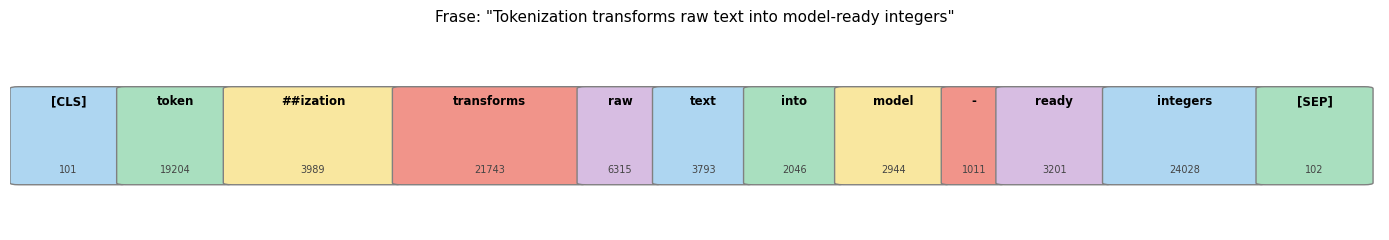


Total de tokens: 12
IDs             : [101, 19204, 3989, 21743, 6315, 3793, 2046, 2944, 1011, 3201, 24028, 102]


In [4]:
# ── Visualização: tokens como blocos coloridos ────────────────────────────────
# Cada token recebe uma cor alternada para tornar a segmentação visual.

frase_demo = "Tokenization transforms raw text into model-ready integers"
encoded    = tokenizer_bert(frase_demo, add_special_tokens=True)
tokens     = tokenizer_bert.convert_ids_to_tokens(encoded['input_ids'])
ids        = encoded['input_ids']

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.axis('off')
ax.set_title(f'Frase: "{frase_demo}"', fontsize=11, pad=14)

cores = ['#AED6F1', '#A9DFBF', '#F9E79F', '#F1948A', '#D7BDE2']
x = 0.0
for i, (tok, tid) in enumerate(zip(tokens, ids)):
    cor = cores[i % len(cores)]
    w   = max(len(tok) * 0.018 + 0.025, 0.055)  # largura proporcional ao texto
    rect = mpatches.FancyBboxPatch(
        (x, 0.25), w, 0.5,
        boxstyle="round,pad=0.01",
        linewidth=1, edgecolor='gray', facecolor=cor
    )
    ax.add_patch(rect)
    ax.text(x + w / 2, 0.68, tok,  ha='center', va='center', fontsize=8.5, fontweight='bold')
    ax.text(x + w / 2, 0.32, str(tid), ha='center', va='center', fontsize=7, color='#444')
    x += w + 0.008

ax.set_xlim(-0.01, x + 0.01)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"\nTotal de tokens: {len(tokens)}")
print(f"IDs             : {ids}")

---

<div align="center">

## <span style="color:#1E90FF;">2. O que são Embeddings?</span>

</div>

Um **embedding** é a tradução de um token (ou de uma sequência inteira) para um **vetor de números reais** em um espaço de alta dimensão.

```
"king"  → [0.21, -0.45, 0.88, ..., 0.03]   # vetor de 768 dimensões no BERT
"queen" → [0.19, -0.41, 0.85, ..., 0.11]   # próximo de "king" nesse espaço
"table" → [-0.72, 0.33, -0.14, ..., 0.60]  # longe de ambos
```

A ideia central é que **proximidade geométrica = proximidade semântica**. Palavras ou frases com significado parecido ficam próximas no espaço vetorial.

### Por que não usar one-hot encoding?

O one-hot encoding representa cada token como um vetor esparso de zeros com apenas um `1` na posição do token:

```
vocabulário = ["rei", "rainha", "mesa"]
"rei"    → [1, 0, 0]
"rainha" → [0, 1, 0]
"mesa"   → [0, 0, 1]
```

O problema: todos os tokens ficam **equidistantes** entre si — não há nenhuma informação semântica codificada na representação. Além disso, o vetor tem tamanho igual ao vocabulário (30.000+ dimensões), tornando-o inviável para modelos.

Os embeddings resolvem isso comprimindo cada token em um vetor **denso e compacto** (128 a 4.096 dimensões) onde a distância entre vetores carrega significado.

### Similaridade de cosseno

A métrica mais usada para comparar embeddings é a **similaridade de cosseno**, que mede o ângulo entre dois vetores (independente do comprimento):

$$\text{cos}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|}$$

- `1.0` → vetores idênticos (mesma direção)
- `0.0` → vetores ortogonais (sem relação semântica)
- `-1.0` → vetores opostos

In [5]:
# ── Extraindo embeddings de frases com BERT ───────────────────────────────────
# Usamos o bert-base-uncased como extrator de features (sem fine-tuning).
# A estratégia de pooling é mean pooling: média dos vetores de todos os tokens
# (excluindo [CLS] e [SEP]), ignorando posições de padding via attention_mask.

MODEL_NAME = 'bert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()  # desativa dropout — modo de inferência

def mean_pooling(model_output, attention_mask):
    """
    Calcula a média dos hidden states de todos os tokens NÃO-padding.
    model_output.last_hidden_state: (batch, seq_len, hidden_dim)
    attention_mask               : (batch, seq_len) — 1 para tokens reais, 0 para padding
    """
    token_embeddings = model_output.last_hidden_state          # (B, L, H)
    mask_expanded    = attention_mask.unsqueeze(-1).float()    # (B, L, 1)
    sum_embeddings   = (token_embeddings * mask_expanded).sum(dim=1)   # (B, H)
    sum_mask         = mask_expanded.sum(dim=1).clamp(min=1e-9)        # (B, 1)
    return sum_embeddings / sum_mask                                    # (B, H)

@torch.no_grad()
def encode(sentences: list[str]) -> np.ndarray:
    """Converte uma lista de frases em embeddings normalizados (L2)."""
    encoded = tokenizer(sentences, padding=True, truncation=True,
                        max_length=128, return_tensors='pt')
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    output  = model(**encoded)
    embeds  = mean_pooling(output, encoded['attention_mask'])
    # normalização L2: coloca todos os vetores na mesma esfera unitária
    embeds  = F.normalize(embeds, p=2, dim=1)
    return embeds.cpu().numpy()

# frases agrupadas por tema
frases_animais   = ["The cat sat on the mat", "Dogs are loyal pets", "Birds can fly high"]
frases_tecnologia = ["Artificial intelligence is transforming industries",
                     "Deep learning requires lots of data",
                     "Neural networks mimic the brain"]
frases_culinaria  = ["The pasta was delicious", "She baked a chocolate cake",
                     "Grilled salmon with lemon sauce"]

todas_frases = frases_animais + frases_tecnologia + frases_culinaria
grupos       = ['animal'] * 3 + ['tecnologia'] * 3 + ['culinária'] * 3
cores_grupos = {'animal': '#E74C3C', 'tecnologia': '#3498DB', 'culinária': '#2ECC71'}

embeddings = encode(todas_frases)
print(f"Shape dos embeddings: {embeddings.shape}")  # (9, 768)

Shape dos embeddings: (9, 768)


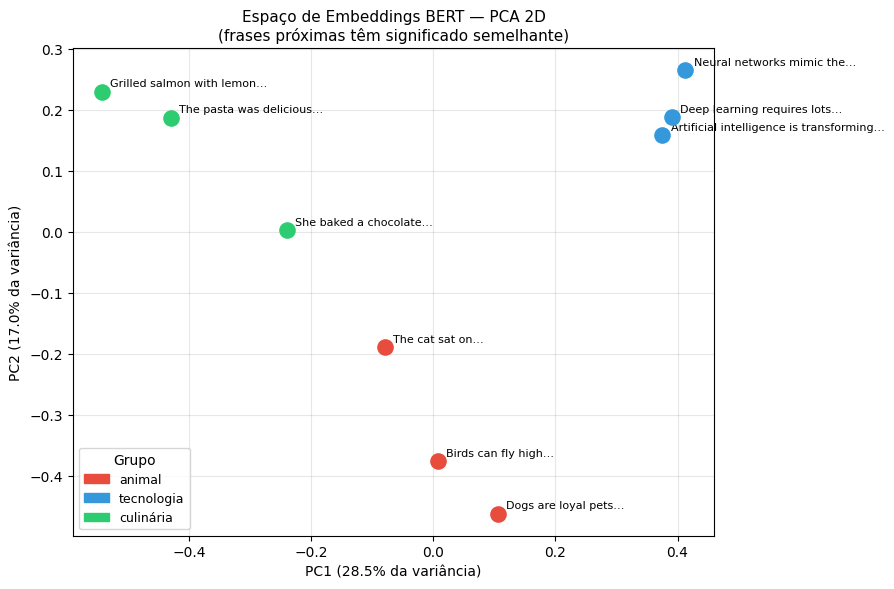

In [6]:
# ── Visualização: PCA 2D dos embeddings ───────────────────────────────────────
# PCA projeta 768 dimensões → 2 dimensões preservando a maior variância.
# Com apenas 9 pontos, PCA é mais estável que t-SNE (que precisa de mais dados).

pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(9, 6))

for i, (frase, grupo) in enumerate(zip(todas_frases, grupos)):
    cor = cores_grupos[grupo]
    ax.scatter(coords[i, 0], coords[i, 1], color=cor, s=120, zorder=3)
    # rótulo curto: primeiras 4 palavras
    rotulo = ' '.join(frase.split()[:4]) + '…'
    ax.annotate(rotulo, (coords[i, 0], coords[i, 1]),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

# legenda dos grupos
handles = [mpatches.Patch(color=c, label=g) for g, c in cores_grupos.items()]
ax.legend(handles=handles, title='Grupo', fontsize=9)
ax.set_title('Espaço de Embeddings BERT — PCA 2D\n(frases próximas têm significado semelhante)',
             fontsize=11)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} da variância)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} da variância)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

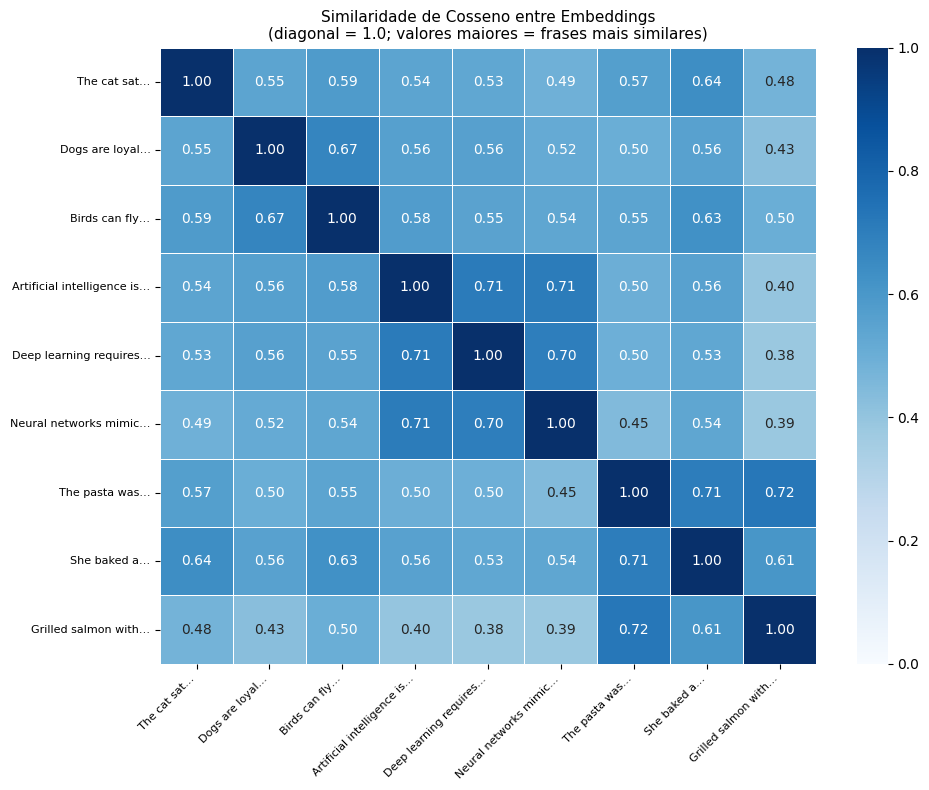

In [7]:
# ── Matriz de similaridade de cosseno ─────────────────────────────────────────
# Como os embeddings já estão normalizados (L2), o produto interno == cosseno.

sim_matrix = embeddings @ embeddings.T  # (9, 9)

# rótulos curtos para o heatmap
rotulos = [' '.join(f.split()[:3]) + '…' for f in todas_frases]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    xticklabels=rotulos, yticklabels=rotulos,
    vmin=0, vmax=1, cmap='Blues', annot=True, fmt='.2f',
    linewidths=0.5, ax=ax
)
ax.set_title('Similaridade de Cosseno entre Embeddings\n(diagonal = 1.0; valores maiores = frases mais similares)',
             fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

---

<div align="center">

## <span style="color:#1E90FF;">3. São Modelos Treináveis?</span>

</div>

**Sim.** A camada de embeddings em PyTorch é um `nn.Embedding` — uma tabela de pesos como qualquer outra. Durante o treinamento, o gradiente flui até ela e os vetores são atualizados pelo otimizador.

Existem três estratégias de uso:

| Estratégia | O que acontece com os pesos? | Quando usar? |
|---|---|---|
| **Treinamento do zero** | Inicializados aleatoriamente, aprendidos do zero | Vocabulário muito específico (código, domínio técnico) |
| **Frozen (congelado)** | Carregados de um modelo pré-treinado, **não atualizados** | Quando os dados de treino são escassos |
| **Fine-tuning** | Carregados de um modelo pré-treinado, **atualizados com LR baixo** | Equilíbrio entre aproveitamento do pré-treino e adaptação ao domínio |

### Como congelar pesos em PyTorch

```python
# congelar toda a camada de embeddings
for param in model.embeddings.parameters():
    param.requires_grad = False

# verificar quais parâmetros serão treinados
treinaveis = sum(p.numel() for p in model.parameters() if p.requires_grad)
total      = sum(p.numel() for p in model.parameters())
print(f"Treináveis: {treinaveis:,} / {total:,}")
```

No BERT, a camada `embeddings` tem três sub-tabelas:
- `word_embeddings`: mapeamento token_id → vetor
- `position_embeddings`: codifica a posição do token na sequência
- `token_type_embeddings`: distingue frases A e B em tarefas de pares

In [8]:
# ── Inspecionando a camada de embeddings do BERT ──────────────────────────────

emb_layer = model.embeddings

print("Subcamadas de model.embeddings:")
for name, module in emb_layer.named_children():
    if hasattr(module, 'weight'):
        shape = tuple(module.weight.shape)
        print(f"  {name:<30} shape={shape}  "
              f"params={module.weight.numel():,}  "
              f"trainable={module.weight.requires_grad}")

total_emb  = sum(p.numel() for p in emb_layer.parameters())
total_bert = sum(p.numel() for p in model.parameters())
print(f"\nParâmetros só nas embeddings : {total_emb:,}")
print(f"Parâmetros totais do BERT    : {total_bert:,}")
print(f"Proporção da camada emb.     : {total_emb / total_bert:.1%}")

Subcamadas de model.embeddings:
  word_embeddings                shape=(30522, 768)  params=23,440,896  trainable=True
  position_embeddings            shape=(512, 768)  params=393,216  trainable=True
  token_type_embeddings          shape=(2, 768)  params=1,536  trainable=True
  LayerNorm                      shape=(768,)  params=768  trainable=True

Parâmetros só nas embeddings : 23,837,184
Parâmetros totais do BERT    : 109,482,240
Proporção da camada emb.     : 21.8%


=== Estratégia: Frozen Embeddings ===
  Treináveis : 85,645,056
  Total      : 109,482,240
  Proporção  : 78.2%

=== Estratégia: Fine-tuning completo ===
  Treináveis : 109,482,240
  Total      : 109,482,240
  Proporção  : 100.0%


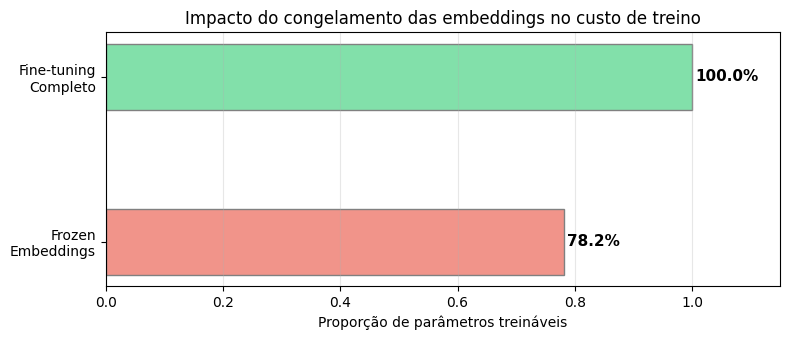

In [9]:
# ── Comparando: frozen vs fine-tunable — contagem de parâmetros ───────────────

def contar_params(model, frozen_embeddings: bool) -> dict:
    # congela ou descongela a camada de embeddings
    for p in model.embeddings.parameters():
        p.requires_grad = not frozen_embeddings

    treinaveis = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total      = sum(p.numel() for p in model.parameters())
    return {'treináveis': treinaveis, 'total': total, 'proporção': treinaveis / total}

frozen_stats   = contar_params(model, frozen_embeddings=True)
finetune_stats = contar_params(model, frozen_embeddings=False)  # restaura estado original

print("=== Estratégia: Frozen Embeddings ===")
print(f"  Treináveis : {frozen_stats['treináveis']:>10,}")
print(f"  Total      : {frozen_stats['total']:>10,}")
print(f"  Proporção  : {frozen_stats['proporção']:.1%}\n")

print("=== Estratégia: Fine-tuning completo ===")
print(f"  Treináveis : {finetune_stats['treináveis']:>10,}")
print(f"  Total      : {finetune_stats['total']:>10,}")
print(f"  Proporção  : {finetune_stats['proporção']:.1%}")

# visualização comparativa
fig, ax = plt.subplots(figsize=(8, 3.5))
estrategias = ['Frozen\nEmbeddings', 'Fine-tuning\nCompleto']
valores     = [frozen_stats['proporção'], finetune_stats['proporção']]
cores_bar   = ['#F1948A', '#82E0AA']

bars = ax.barh(estrategias, valores, color=cores_bar, edgecolor='gray', height=0.4)
for bar, val in zip(bars, valores):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.15)
ax.set_xlabel('Proporção de parâmetros treináveis')
ax.set_title('Impacto do congelamento das embeddings no custo de treino')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


---

<div align="center">

## <span style="color:#1E90FF;">4. Treinando Embeddings do Zero</span>

</div>



Um **embedding** é, no fundo, uma **matriz de pesos** — nada mais. O modelo aprende os valores dessa matriz da mesma forma que aprende qualquer outro peso: calculando gradientes e ajustando com o otimizador.

O algoritmo que vamos implementar é o **Skip-gram** (base do Word2Vec, Mikolov et al., 2013):

> Dado um token **central**, aprenda a prever seus tokens **vizinhos** dentro de uma janela de contexto.

```
"gato  cachorro  animal  doméstico"
         ↑
      centro = "cachorro"   janela = 2
      contextos = ["gato", "animal", "doméstico"]
```

A rede é mínima de propósito:

```
token central  →  nn.Embedding  →  vetor (emb_dim)  →  nn.Linear  →  logits (vocab_size)
```

Não há nada especial aqui. O `nn.Embedding` é uma tabela `(vocab_size × emb_dim)` — o mesmo tipo de objeto que `nn.Linear`. Após o treino, palavras que aparecem em contextos parecidos terão vetores próximos no espaço aprendido.


In [10]:

# ── Corpus e vocabulário ──────────────────────────────────────────────────────
# Corpus pequeno com grupos semânticos propositais.
# Palavras do mesmo grupo co-ocorrem nas mesmas frases — o modelo aprenderá
# essa estrutura sem nenhuma supervisão explícita sobre "grupos".

corpus = [
    "gato cachorro animal doméstico",
    "gato felino doméstico",
    "cachorro cão doméstico",
    "rei rainha realeza trono",
    "rei trono castelo",
    "rainha princesa castelo",
    "paris berlim cidade europa",
    "paris torre museu",
    "berlim roma cidade europa",
    "python código programação",
    "python linguagem software",
    "código software programação",
    "correr nadar esporte",
    "nadar exercício esporte",
    "comida comer alimento",
    "comer alimento refeição",
]

all_words  = [w for sentence in corpus for w in sentence.split()]
vocab      = sorted(set(all_words))
word2idx   = {w: i for i, w in enumerate(vocab)}
idx2word   = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(vocab)

print(f"Frases no corpus     : {len(corpus)}")
print(f"Tokens totais        : {len(all_words)}")
print(f"Vocabulário único    : {VOCAB_SIZE} palavras")
print(f"\n{vocab}")


Frases no corpus     : 16
Tokens totais        : 52
Vocabulário único    : 32 palavras

['alimento', 'animal', 'berlim', 'cachorro', 'castelo', 'cidade', 'comer', 'comida', 'correr', 'cão', 'código', 'doméstico', 'esporte', 'europa', 'exercício', 'felino', 'gato', 'linguagem', 'museu', 'nadar', 'paris', 'princesa', 'programação', 'python', 'rainha', 'realeza', 'refeição', 'rei', 'roma', 'software', 'torre', 'trono']


In [21]:

# ── Geração dos pares (centro, contexto) ─────────────────────────────────────
# Para cada token central, emitimos um par para cada vizinho na janela.
#
# Exemplo com janela=2 para "gato cachorro animal doméstico":
#   centro=gato     → contextos: cachorro, animal
#   centro=cachorro → contextos: gato, animal, doméstico
#   centro=animal   → contextos: gato, cachorro, doméstico
#   centro=doméstico→ contextos: cachorro, animal

WINDOW = 2

def build_skipgram_pairs(corpus, word2idx, window):
    pairs = []
    for sentence in corpus:
        tokens = [word2idx[w] for w in sentence.split()]
        for i, center in enumerate(tokens):
            for offset in range(-window, window + 1):
                j = i + offset
                if offset == 0 or j < 0 or j >= len(tokens):
                    continue
                pairs.append((center, tokens[j]))
    return pairs

pairs    = build_skipgram_pairs(corpus, word2idx, WINDOW)
centers  = torch.tensor([p[0] for p in pairs], dtype=torch.long)
contexts = torch.tensor([p[1] for p in pairs], dtype=torch.long)

print(f"Total de pares (centro, contexto): {len(pairs)}")
print("\nPrimeiros 10 pares:")
for c, ctx in pairs[:10]:
    print(f"  '{idx2word[c]:15s}' → '{idx2word[ctx]}'")


Total de pares (centro, contexto): 112

Primeiros 10 pares:
  'gato           ' → 'cachorro'
  'gato           ' → 'animal'
  'cachorro       ' → 'gato'
  'cachorro       ' → 'animal'
  'cachorro       ' → 'doméstico'
  'animal         ' → 'gato'
  'animal         ' → 'cachorro'
  'animal         ' → 'doméstico'
  'doméstico      ' → 'cachorro'
  'doméstico      ' → 'animal'


In [12]:

# ── Modelo Skip-gram ──────────────────────────────────────────────────────────
# Arquitetura propositalmente mínima para deixar claro o que está sendo treinado:
#
#   nn.Embedding  → a tabela de vetores (VOCAB_SIZE × EMB_DIM)
#   nn.Linear     → projeção do vetor para logits sobre o vocabulário
#
# Durante o treino, o otimizador ajusta AMBAS as matrizes de pesos.
# Ao final, model_sg.embeddings.weight contém os vetores aprendidos.

class SkipGram(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, emb_dim)   # ← ISSO é o embedding
        self.out        = nn.Linear(emb_dim, vocab_size, bias=False)

    def forward(self, center):
        emb    = self.embeddings(center)   # (batch, emb_dim)   — lookup na tabela
        logits = self.out(emb)             # (batch, vocab_size) — projeção linear
        return logits

EMB_DIM  = 16
model_sg = SkipGram(VOCAB_SIZE, EMB_DIM)

total_params = sum(p.numel() for p in model_sg.parameters())
emb_params   = VOCAB_SIZE * EMB_DIM
print(f"Parâmetros totais                : {total_params:,}")
print(f"Parâmetros em nn.Embedding       : {emb_params:,}  ({emb_params/total_params:.0%})")
print(f"\nFormato da tabela de embeddings  : ({VOCAB_SIZE} palavras × {EMB_DIM} dims)")
print(f"→ {emb_params} números que serão aprendidos do zero pelo otimizador")


Parâmetros totais                : 1,024
Parâmetros em nn.Embedding       : 512  (50%)

Formato da tabela de embeddings  : (32 palavras × 16 dims)
→ 512 números que serão aprendidos do zero pelo otimizador


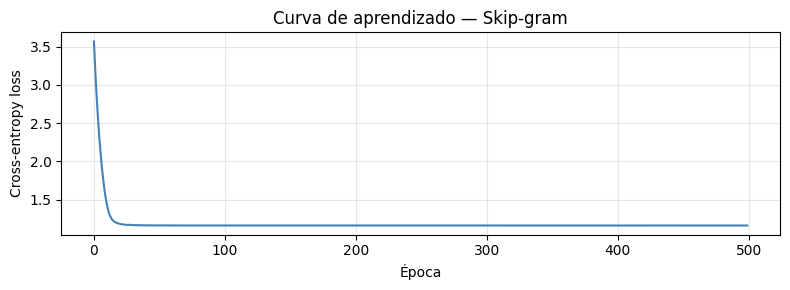

Loss inicial : 3.5650
Loss final   : 1.1643


In [13]:

# ── Treino ────────────────────────────────────────────────────────────────────
# Objetivo: dado o token central, prever o token de contexto (cross-entropy).
# Após o treino, palavras que aparecem em contextos semelhantes terão vetores
# próximos — sem que ninguém tenha definido o que "similar" significa.

torch.manual_seed(42)

EPOCHS = 500
LR     = 0.05

optimizer = torch.optim.Adam(model_sg.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

losses = []
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    logits = model_sg(centers)          # (N, VOCAB_SIZE)
    loss   = criterion(logits, contexts)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Curva de aprendizado
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, color='steelblue', lw=1.5)
ax.set_xlabel("Época")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Curva de aprendizado — Skip-gram")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loss inicial : {losses[0]:.4f}")
print(f"Loss final   : {losses[-1]:.4f}")


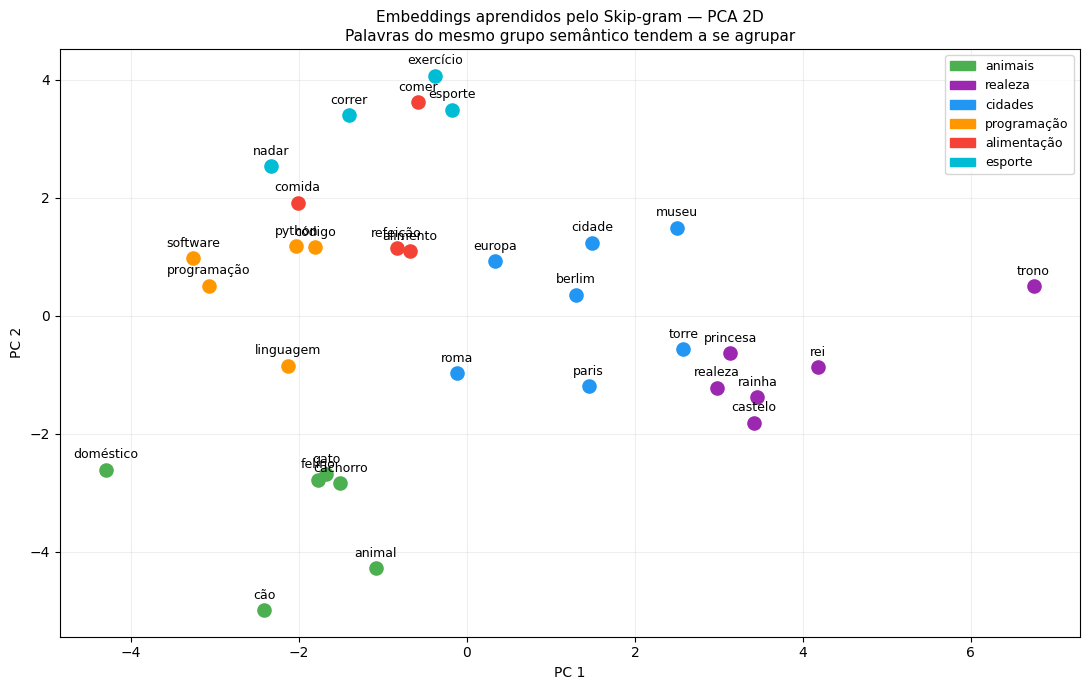

In [14]:

# ── Visualização: embeddings aprendidos (PCA 2D) ──────────────────────────────
# Palavras que aparecem nos mesmos contextos no corpus devem se agrupar.
# Se o treino funcionou, os grupos semânticos ficarão visivelmente separados.

emb_matrix = model_sg.embeddings.weight.detach().numpy()   # (VOCAB_SIZE, EMB_DIM)
emb_2d     = PCA(n_components=2).fit_transform(emb_matrix)

group_colors = {
    "animais":      ("#4CAF50", ["gato","cachorro","animal","doméstico","felino","cão"]),
    "realeza":      ("#9C27B0", ["rei","rainha","realeza","trono","princesa","castelo"]),
    "cidades":      ("#2196F3", ["paris","berlim","roma","cidade","europa","torre","museu"]),
    "programação":  ("#FF9800", ["python","código","programação","linguagem","software"]),
    "alimentação":  ("#F44336", ["comida","comer","alimento","refeição"]),
    "esporte":      ("#00BCD4", ["correr","nadar","esporte","exercício"]),
}

fig, ax = plt.subplots(figsize=(11, 7))
legend_patches = []

for group, (color, words) in group_colors.items():
    xs, ys, labels = [], [], []
    for w in words:
        if w in word2idx:
            xs.append(emb_2d[word2idx[w], 0])
            ys.append(emb_2d[word2idx[w], 1])
            labels.append(w)
    ax.scatter(xs, ys, color=color, s=90, zorder=3)
    for x, y, lbl in zip(xs, ys, labels):
        ax.annotate(lbl, (x, y), fontsize=9, ha='center', va='bottom',
                    xytext=(0, 6), textcoords='offset points')
    legend_patches.append(mpatches.Patch(color=color, label=group))

ax.legend(handles=legend_patches, loc='best', fontsize=9)
ax.set_title("Embeddings aprendidos pelo Skip-gram — PCA 2D\n"
             "Palavras do mesmo grupo semântico tendem a se agrupar", fontsize=11)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [15]:

# ── Vizinhos mais próximos ────────────────────────────────────────────────────
# Dado um token, quais são os vetores mais similares no espaço aprendido?
# Similaridade de cosseno sobre os embeddings normalizados.

def nearest_neighbors(word, k=4):
    if word not in word2idx:
        print(f"'{word}' não está no vocabulário.")
        return
    embs   = model_sg.embeddings.weight.detach()
    embs_n = F.normalize(embs, dim=1)
    query  = embs_n[word2idx[word]].unsqueeze(0)
    sims   = (embs_n @ query.T).squeeze()
    top_k  = sims.topk(k + 1).indices.tolist()
    print(f"Vizinhos de '{word}':")
    for i in top_k:
        if i != word2idx[word]:
            print(f"  {idx2word[i]:20s}  sim = {sims[i]:.3f}")

for query_word in ["gato", "rei", "python", "paris"]:
    nearest_neighbors(query_word)
    print()


Vizinhos de 'gato':
  animal                sim = 0.606
  cão                   sim = 0.547
  doméstico             sim = 0.424
  cachorro              sim = 0.349

Vizinhos de 'rei':
  princesa              sim = 0.578
  castelo               sim = 0.437
  rainha                sim = 0.428
  realeza               sim = 0.362

Vizinhos de 'python':
  software              sim = 0.518
  código                sim = 0.377
  programação           sim = 0.247
  comida                sim = 0.156

Vizinhos de 'paris':
  roma                  sim = 0.515
  europa                sim = 0.432
  animal                sim = 0.266
  torre                 sim = 0.171




---

<div align="center">

## <span style="color:#1E90FF;">5. Criando um Modelo de Sentence Embeddings</span>

</div>


Vamos construir um **modelo de sentence embeddings** do zero, encapsulando o pipeline completo em uma classe PyTorch. A arquitetura segue o padrão dos modelos da família **Sentence-BERT (SBERT)**:

```
Entrada (texto)
     ↓
 Tokenizador          — transforma texto em input_ids e attention_mask
     ↓
 Encoder (BERT)       — produz hidden states para cada token (shape: B × L × H)
     ↓
 Mean Pooling         — colapsa a dimensão de sequência (shape: B × H)
     ↓
 Projeção Linear      — reduz dimensão: H → D (opcional, ex: 768 → 256)
     ↓
 Normalização L2      — coloca todos os vetores na esfera unitária
     ↓
 Embedding da frase   — vetor final de dimensão D
```

O treinamento é feito com **Contrastive Loss**: dados pares de frases rotulados como similares (`label=1`) ou dissimilares (`label=0`), a loss empurra pares similares para próximos e pares dissimilares para longe.

$$\mathcal{L} = y \cdot d^2 + (1-y) \cdot \max(0,\, m - d)^2$$

onde $d$ é a distância euclidiana entre os dois embeddings e $m$ é uma margem mínima para pares negativos.

In [16]:
class SentenceEmbedder(nn.Module):
    """
    Modelo de sentence embeddings baseado em BERT com projeção linear opcional.

    Arquitetura:
        BERT encoder  →  mean pooling  →  Linear(hidden_dim → embed_dim)  →  L2 norm

    Args:
        model_name : nome do modelo HuggingFace a usar como encoder
        embed_dim  : dimensão final do embedding (None = manter dimensão do encoder)
        freeze_bert: se True, congela todos os pesos do BERT (só treina a projeção)
    """

    def __init__(self, model_name: str, embed_dim: int = 256, freeze_bert: bool = False):
        super().__init__()
        self.tokenizer  = AutoTokenizer.from_pretrained(model_name)
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden_dim      = self.encoder.config.hidden_size  # 768 para BERT-base

        # projeção: reduz 768 → embed_dim para embeddings mais compactos
        self.projection = nn.Linear(hidden_dim, embed_dim)

        if freeze_bert:
            for param in self.encoder.parameters():
                param.requires_grad = False

    def _mean_pool(self, last_hidden_state: torch.Tensor,
                   attention_mask: torch.Tensor) -> torch.Tensor:
        mask     = attention_mask.unsqueeze(-1).float()
        summed   = (last_hidden_state * mask).sum(dim=1)
        counts   = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    def forward(self, sentences: list[str]) -> torch.Tensor:
        # tokenização inline — facilita o uso mas pode ser separada para performance
        encoded = self.tokenizer(
            sentences, padding=True, truncation=True,
            max_length=128, return_tensors='pt'
        )
        encoded = {k: v.to(next(self.parameters()).device) for k, v in encoded.items()}

        output   = self.encoder(**encoded)
        pooled   = self._mean_pool(output.last_hidden_state, encoded['attention_mask'])
        projected = self.projection(pooled)                  # (B, embed_dim)
        return F.normalize(projected, p=2, dim=1)            # normalização L2

    @torch.no_grad()
    def embed(self, sentences: list[str]) -> np.ndarray:
        """Atalho para inferência: retorna numpy sem gradiente."""
        self.eval()
        return self.forward(sentences).cpu().numpy()


# instancia o modelo com BERT congelado (só a projeção é treinável)
embedder = SentenceEmbedder('bert-base-uncased', embed_dim=256, freeze_bert=True).to(DEVICE)

total      = sum(p.numel() for p in embedder.parameters())
treinaveis = sum(p.numel() for p in embedder.parameters() if p.requires_grad)
print(f"Parâmetros totais     : {total:,}")
print(f"Parâmetros treináveis : {treinaveis:,}  ({treinaveis/total:.1%} — apenas a projeção)")
print(f"\nArquitetura da projeção:")
print(embedder.projection)

Parâmetros totais     : 109,679,104
Parâmetros treináveis : 196,864  (0.2% — apenas a projeção)

Arquitetura da projeção:
Linear(in_features=768, out_features=256, bias=True)


In [17]:
# ── Dataset de pares para treinamento com Contrastive Loss ────────────────────
# Cada amostra é um par (frase_a, frase_b, label):
#   label = 1  →  frases similares (mesma temática / semântica próxima)
#   label = 0  →  frases dissimilares (temáticas diferentes)

pares_similares = [
    ("I love playing soccer", "Football is my favorite sport"),
    ("The movie was fantastic", "I really enjoyed the film"),
    ("She is learning to code", "Programming is her new hobby"),
    ("The stock market crashed", "Investors lost money today"),
    ("Deep learning is powerful", "Neural networks solve complex problems"),
    ("He went for a morning run", "She jogged in the park at dawn"),
]

pares_dissimilares = [
    ("I love playing soccer", "The recipe calls for two eggs"),
    ("The movie was fantastic", "Interest rates are rising"),
    ("She is learning to code", "The cat sat on the mat"),
    ("The stock market crashed", "I baked a delicious pie"),
    ("Deep learning is powerful", "The sunset was beautiful"),
    ("He went for a morning run", "Quantum computing is complex"),
]

# une e cria os rótulos
pares  = pares_similares + pares_dissimilares
labels = [1] * len(pares_similares) + [0] * len(pares_dissimilares)

print(f"Total de pares: {len(pares)}  ({len(pares_similares)} similares + {len(pares_dissimilares)} dissimilares)")

Total de pares: 12  (6 similares + 6 dissimilares)


In [18]:
# ── Loop de treinamento com Contrastive Loss ──────────────────────────────────

EPOCHS   = 20
LR       = 3e-4   # LR mais alto: só a projeção linear está sendo treinada
MARGIN   = 1.0    # margem para pares negativos na contrastive loss

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, embedder.parameters()), lr=LR
)

def contrastive_loss(emb_a: torch.Tensor, emb_b: torch.Tensor,
                     label: torch.Tensor, margin: float = 1.0) -> torch.Tensor:
    """
    emb_a, emb_b : tensores (B, D) já normalizados
    label        : tensor (B,) com 1=similar, 0=dissimilar
    """
    # distância euclidiana entre os pares
    dist = F.pairwise_distance(emb_a, emb_b, p=2)

    # loss para pares similares: minimiza a distância
    loss_pos = label * dist.pow(2)

    # loss para pares dissimilares: maximiza a distância até a margem
    loss_neg = (1 - label) * F.relu(margin - dist).pow(2)

    return (loss_pos + loss_neg).mean()

historico_loss = []

embedder.train()
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    # extrai frases A e B separadamente
    frases_a = [p[0] for p in pares]
    frases_b = [p[1] for p in pares]
    lbl_t    = torch.tensor(labels, dtype=torch.float32).to(DEVICE)

    # forward: cada chamada ao embedder tokeniza, passa pelo encoder e projeta
    emb_a = embedder(frases_a)
    emb_b = embedder(frases_b)

    loss = contrastive_loss(emb_a, emb_b, lbl_t, margin=MARGIN)
    loss.backward()
    optimizer.step()

    historico_loss.append(loss.item())
    if epoch % 5 == 0 or epoch == 1:
        print(f"Época {epoch:>3}/{EPOCHS}  |  Contrastive Loss: {loss.item():.4f}")

print("\nTreinamento concluído.")

Época   1/20  |  Contrastive Loss: 0.3030
Época   5/20  |  Contrastive Loss: 0.1308
Época  10/20  |  Contrastive Loss: 0.0916
Época  15/20  |  Contrastive Loss: 0.0669
Época  20/20  |  Contrastive Loss: 0.0495

Treinamento concluído.


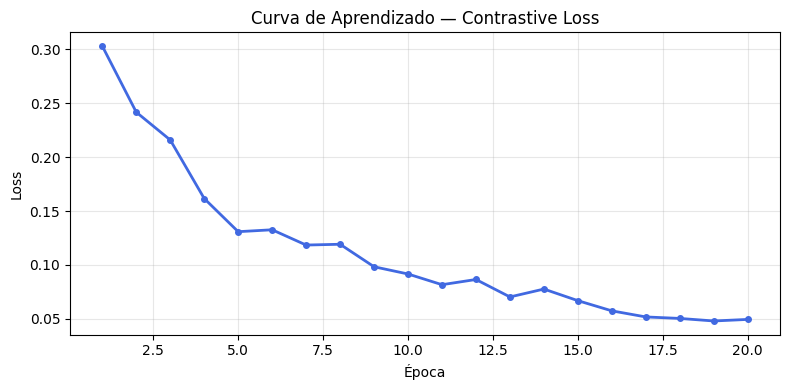


=== Distâncias após o treinamento ===

Par                                                           Label   Distância
--------------------------------------------------------------------------------
I love playing soccer… / Football is my favorite …           SIMILAR      0.1322
The movie was fantastic… / I really enjoyed the fil…         SIMILAR      0.1356
She is learning to code… / Programming is her new h…         SIMILAR      0.1812
The stock market crashed… / Investors lost money tod…        SIMILAR      0.1709
Deep learning is powerful… / Neural networks solve co…       SIMILAR      0.1547
He went for a morning run… / She jogged in the park a…       SIMILAR      0.1509
I love playing soccer… / The recipe calls for two…           DÍSPAR       1.0022
The movie was fantastic… / Interest rates are risin…         DÍSPAR       0.8814
She is learning to code… / The cat sat on the mat…           DÍSPAR       0.9139
The stock market crashed… / I baked a delicious pie…         DÍSPAR   

In [19]:
# ── Curva de aprendizado ──────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), historico_loss, color='royalblue', linewidth=2, marker='o', markersize=4)
ax.set_title('Curva de Aprendizado — Contrastive Loss', fontsize=12)
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Avaliação qualitativa ─────────────────────────────────────────────────────
# Verificamos se o modelo aprendeu a separar pares similares de dissimilares.

print("\n=== Distâncias após o treinamento ===\n")
print(f"{'Par':<60} {'Label':>6}  {'Distância':>10}")
print("-" * 80)

embedder.eval()
with torch.no_grad():
    for (fa, fb), lbl in zip(pares, labels):
        ea   = embedder([fa])
        eb   = embedder([fb])
        dist = float(F.pairwise_distance(
            torch.tensor(ea), torch.tensor(eb), p=2
        ).item())
        tipo = "SIMILAR" if lbl == 1 else "DÍSPAR "
        linha = f"{fa[:28]}… / {fb[:24]}…"
        print(f"{linha:<60} {tipo:>6}  {dist:>10.4f}")

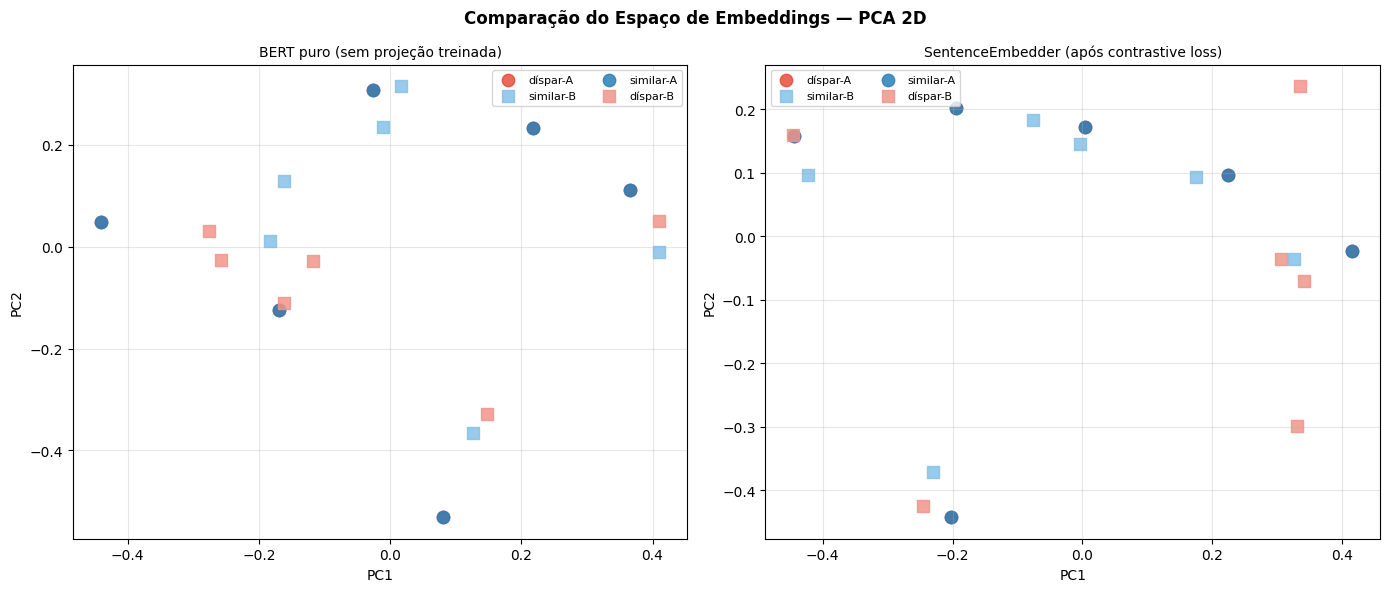

In [20]:
# ── Visualização final: espaço aprendido pelo SentenceEmbedder ────────────────
# Comparamos os embeddings ANTES (BERT puro) e DEPOIS (após treino da projeção).

frases_eval = [fa for fa, fb in pares] + [fb for fa, fb in pares]
grupos_eval = (
    ['similar-A' if l == 1 else 'díspar-A' for l in labels] +
    ['similar-B' if l == 1 else 'díspar-B' for l in labels]
)

# embeddings do modelo treinado
embs_treinado = embedder.embed(frases_eval)  # (24, 256)

# embeddings do BERT puro (sem projeção) usando a função encode() da seção 2
embs_bert = encode(frases_eval)  # (24, 768)

# redução para 2D com PCA
pca_treinado = PCA(n_components=2, random_state=42).fit_transform(embs_treinado)
pca_bert     = PCA(n_components=2, random_state=42).fit_transform(embs_bert)

cores_eval = {
    'similar-A': '#2980B9', 'similar-B': '#85C1E9',
    'díspar-A':  '#E74C3C', 'díspar-B':  '#F1948A',
}
markers_eval = {
    'similar-A': 'o', 'similar-B': 's',
    'díspar-A':  'o', 'díspar-B':  's',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, coords, titulo in zip(
    axes,
    [pca_bert, pca_treinado],
    ['BERT puro (sem projeção treinada)', 'SentenceEmbedder (após contrastive loss)']
):
    for grupo in set(grupos_eval):
        idx = [i for i, g in enumerate(grupos_eval) if g == grupo]
        ax.scatter(
            coords[idx, 0], coords[idx, 1],
            c=cores_eval[grupo], marker=markers_eval[grupo],
            label=grupo, s=80, alpha=0.85
        )
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('Comparação do Espaço de Embeddings — PCA 2D', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

<div align="center">

## <span style="color:#1E90FF;">Resumo</span>

</div>

| Conceito | O que é | Para que serve |
|---|---|---|
| **Token** | Unidade mínima de texto (subpalavra, palavra ou caractere) processada pelo modelo | Converte texto em inteiros que o modelo consegue processar |
| **Embedding** | Vetor denso de números reais que representa um token ou sequência | Codifica significado semântico em um espaço geométrico |
| **Mean Pooling** | Média dos vetores de todos os tokens da sequência | Produz um único vetor representando a frase inteira |
| **Normalização L2** | Projeta todos os vetores na esfera unitária | Permite usar produto interno como proxy de similaridade de cosseno |
| **Contrastive Loss** | Função de custo baseada em pares similares/dissimilares | Treina o modelo a aproximar frases semanticamente próximas |
| **Freeze / Fine-tune** | Congela ou libera pesos do encoder | Controla o trade-off entre custo computacional e adaptação ao domínio |

### Aplicações práticas de embeddings

- **Busca semântica**: encontrar documentos por significado, não por palavra-chave exata
- **Detecção de duplicatas**: identificar perguntas ou tickets de suporte redundantes
- **Sistemas de recomendação**: recomendar itens com base na similaridade de descrições
- **Clustering de textos**: agrupar documentos sem rótulos (aprendizado não supervisionado)
- **RAG (Retrieval-Augmented Generation)**: recuperar trechos relevantes para alimentar um LLM